# Analysing NLP Features
Confirming text aligns with scores issued

#### Load Parquets

In [6]:
import pandas as pd

In [9]:
nlp = pd.read_parquet("../data/dataset/stock_tweets_sentiment_emotion_stanceScore_finbert_nomerge.parquet")


In [10]:
nlp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106338 entries, 0 to 106337
Data columns (total 33 columns):
 #   Column                   Non-Null Count   Dtype              
---  ------                   --------------   -----              
 0   ticker                   106338 non-null  object             
 1   text                     106338 non-null  object             
 2   created_at               106338 non-null  datetime64[ns, UTC]
 3   user_id                  106338 non-null  object             
 4   date                     106338 non-null  object             
 5   sentiment                106338 non-null  int64              
 6   emotion_anger            106338 non-null  float64            
 7   emotion_disgust          106338 non-null  float64            
 8   emotion_fear             106338 non-null  float64            
 9   emotion_joy              106338 non-null  float64            
 10  emotion_neutral          106338 non-null  float64            
 11  emotion_sadne

### Sample Spot Check

In [12]:
pd.set_option("display.max_colwidth", None)

import random

sample_size = random.randint(50, 100)

def review_sample(df, cols, label):
    sample = df.sample(n=sample_size, random_state=42).copy()
    print(f"\n=== {label} (n={sample_size}) ===")
    display(sample[cols])
    return sample

nlp_cols = [
    "ticker", "text", "sentiment",
    "emotion_anger", "emotion_disgust", "emotion_fear",
    "emotion_joy", "emotion_neutral", "emotion_sadness",
    "emotion_surprize", "stance_label", "stance_score", 
    "emotion_anger_pct", "emotion_disgust_pct", "emotion_fear_pct",
    "emotion_joy_pct", "emotion_neutral_pct", "emotion_sadness_pct",
    "emotion_surprize_pct", 
    "positive_emotion", "negative_emotion", "uncertainty_emotion",
    "positive_emotion_pct", "negative_emotion_pct", "uncertainty_emotion_pct",
    "finbert_label", "finbert_score", "finbert_up", "finbert_down", "finbert_neutral"
]

raw_sample = review_sample(nlp, nlp_cols, "Finalised NLP Dataset Sample")



=== Finalised NLP Dataset Sample (n=71) ===


,ticker,text,sentiment,emotion_anger,emotion_disgust,emotion_fear,emotion_joy,emotion_neutral,emotion_sadness,emotion_surprize,...,negative_emotion,uncertainty_emotion,positive_emotion_pct,negative_emotion_pct,uncertainty_emotion_pct,finbert_label,finbert_score,finbert_up,finbert_down,finbert_neutral
52117,FB,are you putting your money in dnkn al life goto,1,0.670027,0.153461,0.054237,0.051480,0.035466,0.028790,0.006538,...,0.852278,0.060775,0.688258,1.861912,1.194314,neutral,0.927887,0.052065,0.020047,0.927887
89214,PFE,press reporting interested in buying azn would certainly get into immunooncology will be interesting to …,3,0.823238,0.114829,0.033614,0.009037,0.008282,0.008008,0.002992,...,0.946075,0.036606,0.071038,1.631138,0.853157,neutral,0.904802,0.082817,0.012381,0.904802
73475,JPM,tampa event tonight p m et fdic bank closers visit xlf wfc ms met gs c bac axp spy dia qqq dxf,5,0.342155,0.294037,0.286387,0.063986,0.009914,0.002975,0.000546,...,0.639167,0.286933,0.764910,1.010909,1.019316,neutral,0.932953,0.043311,0.023736,0.932953
11181,AAPL,newsxom newssdrl newssdrl toptickertweets spy tza tsla ll twtr sdrl iaci rig xom sent …,1,0.603495,0.279451,0.051712,0.040406,0.011639,0.011402,0.001895,...,0.894348,0.053607,0.597764,1.912900,0.779994,neutral,0.908606,0.074771,0.016623,0.908606
51043,FB,stifel nicolaus deutsche bank and merrill lynch reiterated a buy,1,0.492071,0.362203,0.063605,0.036789,0.023656,0.019687,0.001991,...,0.873960,0.065596,0.559969,2.047086,0.884040,neutral,0.780446,0.203313,0.016241,0.780446
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57403,FB,valaafshar market cap billions aapl b goog b goog b msft b …,1,0.526829,0.214995,0.132951,0.047287,0.044369,0.024894,0.008675,...,0.766718,0.141626,0.658871,1.762982,1.631073,neutral,0.920993,0.059619,0.019388,0.920993
3580,AAPL,tbt remember when tim cook was the worst ceo ever that was cool,1,0.574244,0.206015,0.094803,0.066567,0.032798,0.013813,0.011760,...,0.794072,0.106563,0.784546,1.694653,1.499408,neutral,0.532003,0.024268,0.443729,0.532003
63950,GOOG,amzn in talks to buy grpn for b fb should have bought them instead of oculus will step in,1,0.548114,0.248833,0.166468,0.022855,0.007194,0.004557,0.001978,...,0.801504,0.168446,0.360407,1.344769,1.324475,neutral,0.912221,0.075091,0.012688,0.912221
83741,MSFT,our pick on ppch is up for our subscribers big news xlf f fn,5,0.774734,0.137120,0.058185,0.011869,0.011702,0.005545,0.000846,...,0.917398,0.059030,0.134514,1.473236,0.443802,neutral,0.903158,0.084379,0.012464,0.903158


# Sanity Distribution
Looking out for extreme skews

<Axes: title={'center': 'Sentiment frequency (1-5)'}, xlabel='sentiment'>

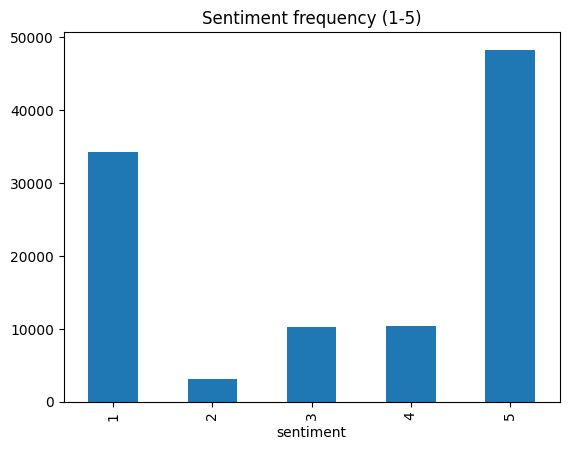

In [14]:
nlp["sentiment"].value_counts().sort_index().plot(
    kind="bar", title="Sentiment frequency (1-5)"
)

<Axes: title={'center': 'Stance label frequency'}, xlabel='stance_label'>

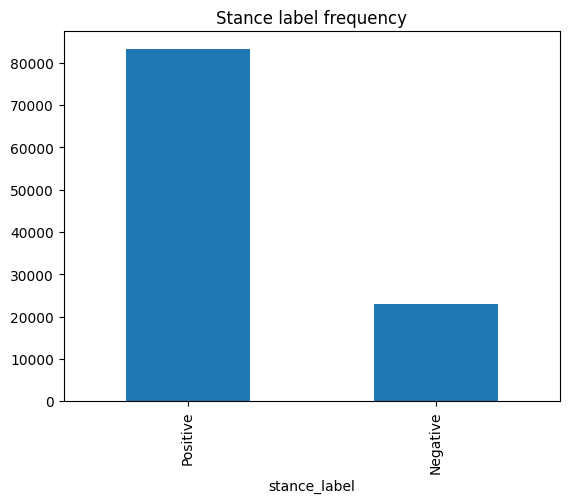

In [15]:
# Label frequency plots
nlp["stance_label"].value_counts().plot(kind="bar", title="Stance label frequency")

<Axes: title={'center': 'Finbert label frequency'}, xlabel='finbert_label'>

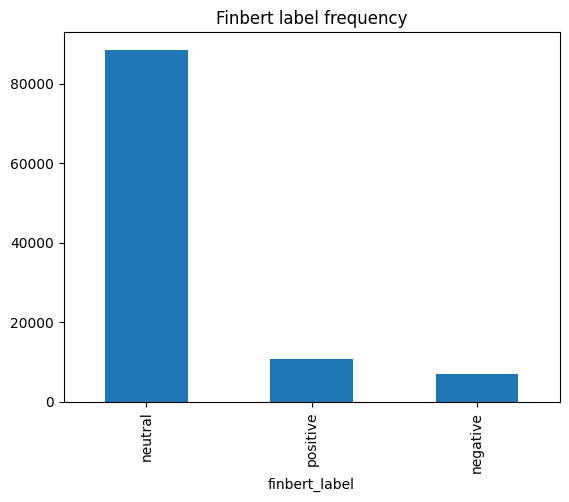

In [16]:
# Finbert Stance label frequency plot
nlp["finbert_label"].value_counts().plot(kind="bar", title="Finbert label frequency")

Raw stance_label distribution:
 stance_label
Positive    0.782956
Negative    0.217044
Name: proportion, dtype: float64
Unified stance_label distribution:
 finbert_label
neutral     0.832684
positive    0.100613
negative    0.066702
Name: proportion, dtype: float64
Raw out-of-bounds counts:
 emotion_anger       0
emotion_disgust     0
emotion_fear        0
emotion_joy         0
emotion_neutral     0
emotion_sadness     0
emotion_surprize    0
dtype: int64
Unified out-of-bounds counts:
 positive_emotion       0
negative_emotion       0
uncertainty_emotion    0
dtype: int64


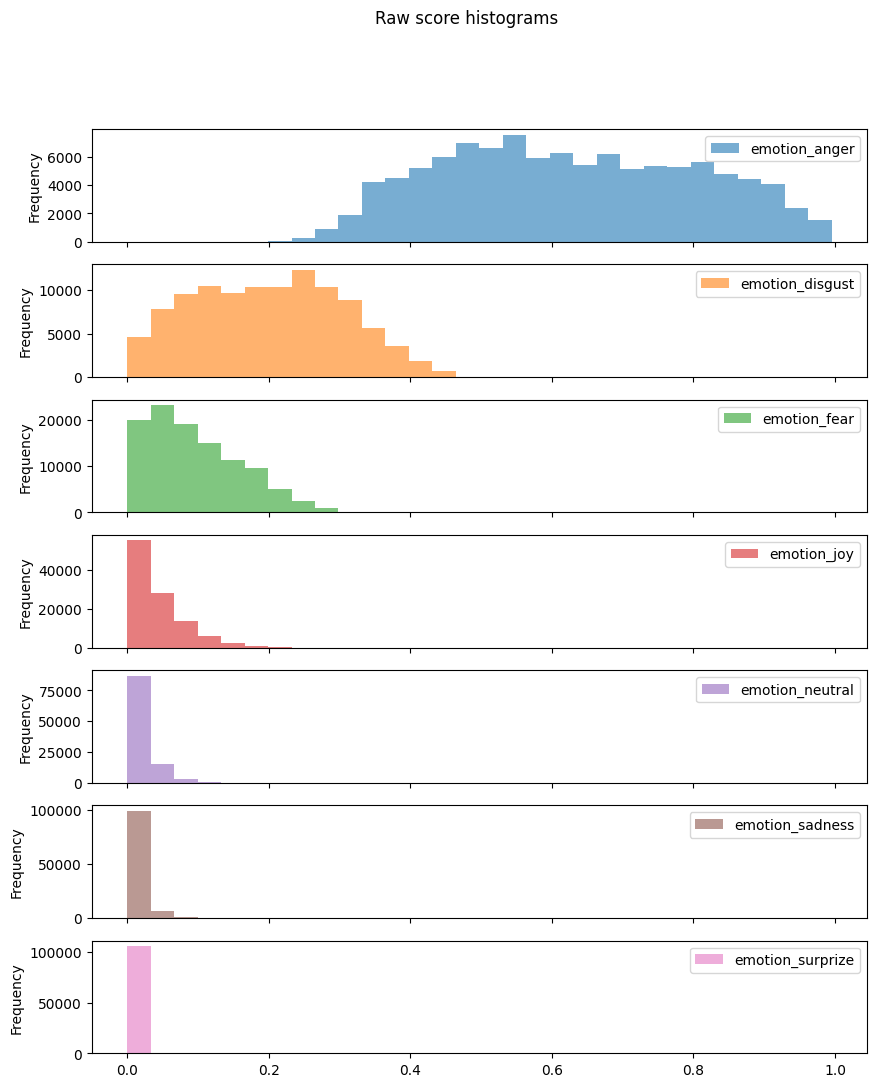

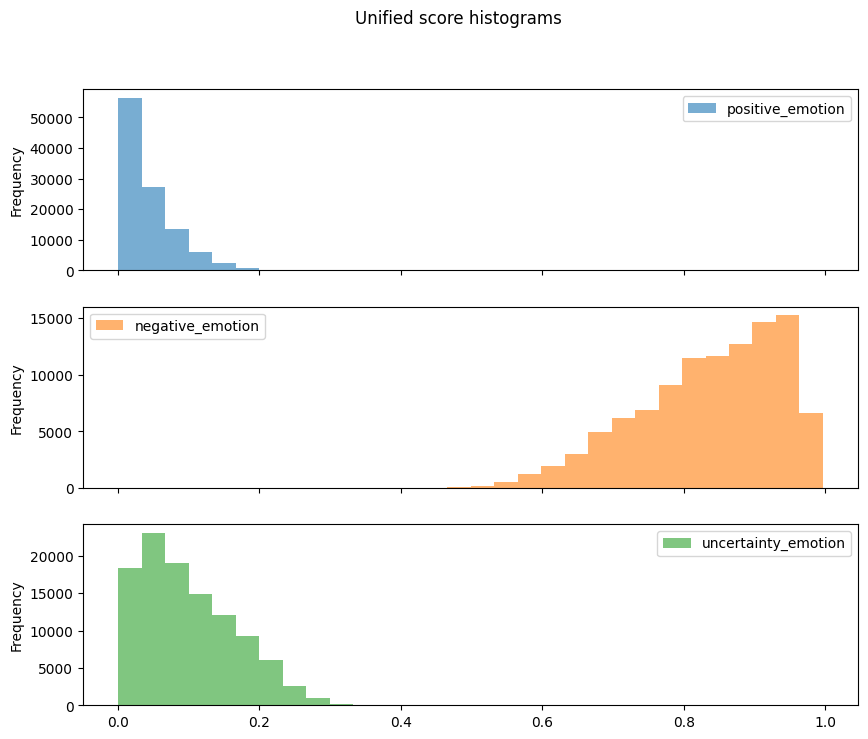

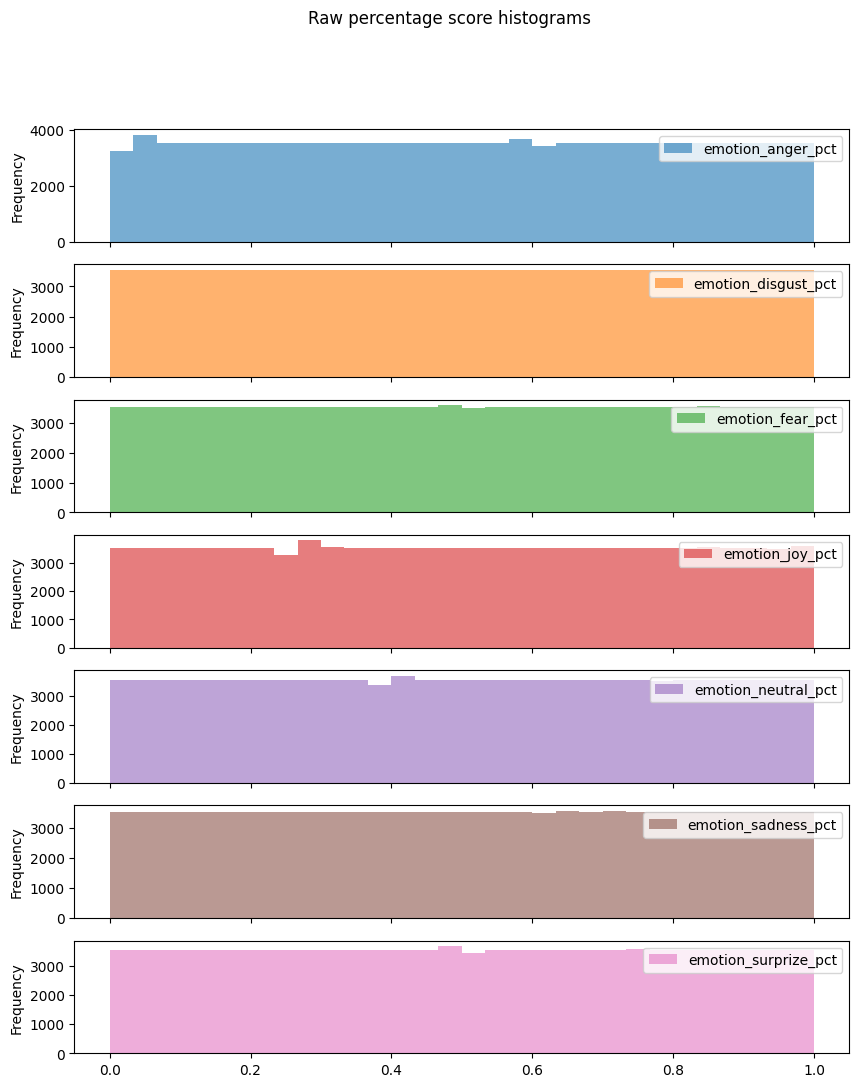

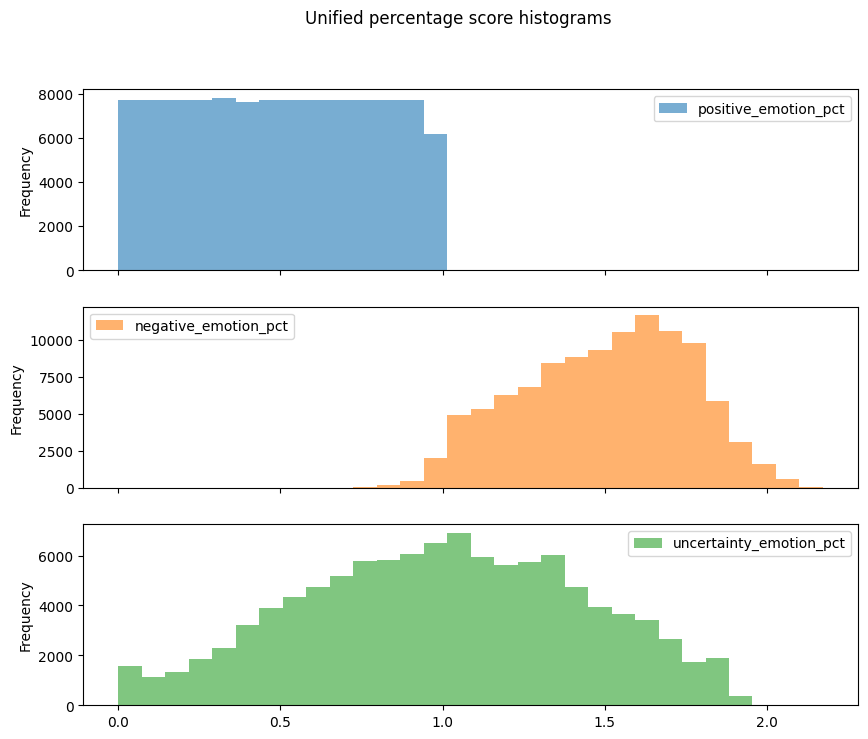

In [18]:
# Score histograms
raw_score_cols = [
    "emotion_anger", "emotion_disgust", "emotion_fear", "emotion_joy",
    "emotion_neutral", "emotion_sadness", "emotion_surprize"
]
unify_score_cols = ["positive_emotion", "negative_emotion", "uncertainty_emotion"]

raw_pct_score_cols = [
    "emotion_anger_pct", "emotion_disgust_pct", "emotion_fear_pct",
     "emotion_joy_pct", "emotion_neutral_pct", "emotion_sadness_pct",
     "emotion_surprize_pct"
]

unify_pct_score_cols = ["positive_emotion_pct", "negative_emotion_pct", "uncertainty_emotion_pct"]

nlp[raw_score_cols].plot(kind="hist", bins=30, alpha=0.6, subplots=True, figsize=(10, 12), title="Raw score histograms")
nlp[unify_score_cols].plot(kind="hist", bins=30, alpha=0.6, subplots=True, figsize=(10, 8), title="Unified score histograms")
nlp[raw_pct_score_cols].plot(kind="hist", bins=30, alpha=0.6, subplots=True, figsize=(10, 12), title="Raw percentage score histograms")
nlp[unify_pct_score_cols].plot(kind="hist", bins=30, alpha=0.6, subplots=True, figsize=(10, 8), title="Unified percentage score histograms")

# Impossible values check (outside [0, 1])
raw_out_of_bounds = (nlp[raw_score_cols] < 0) | (nlp[raw_score_cols] > 1)
unify_out_of_bounds = (nlp[unify_score_cols] < 0) | (nlp[unify_score_cols] > 1)

nlp['stance_label'].value_counts(normalize=True)
nlp['finbert_label'].value_counts(normalize=True)

print("Raw stance_label distribution:\n", nlp['stance_label'].value_counts(normalize=True))
print("Unified stance_label distribution:\n", nlp['finbert_label'].value_counts(normalize=True))

print("Raw out-of-bounds counts:\n", raw_out_of_bounds.sum())
print("Unified out-of-bounds counts:\n", unify_out_of_bounds.sum())



array([<Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>,
       <Axes: ylabel='Frequency'>], dtype=object)

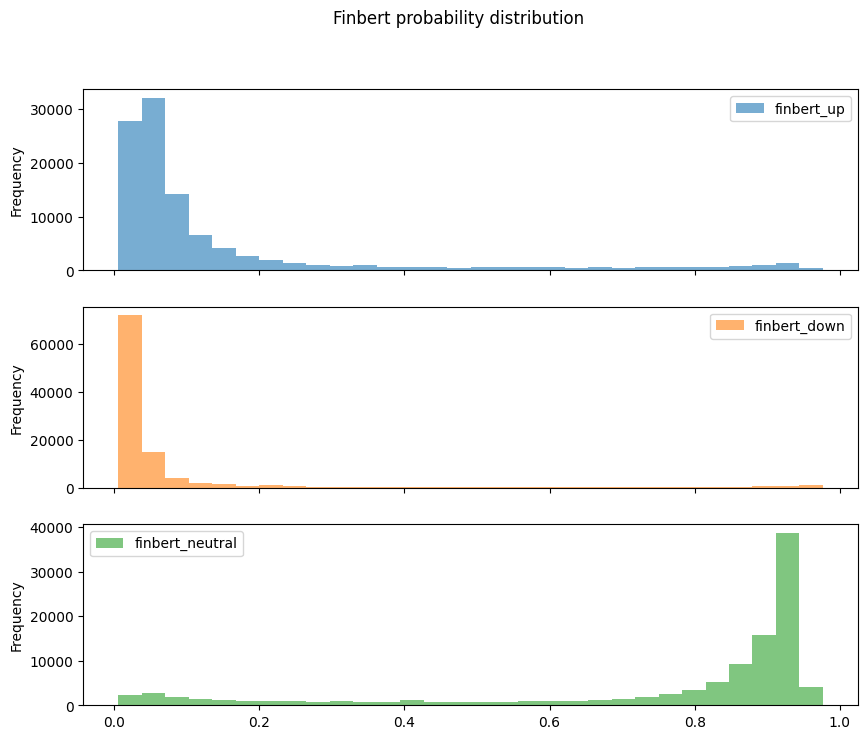

In [20]:
# Finbert Probability distribution plot
nlp[["finbert_up", "finbert_down", "finbert_neutral"]].plot(kind="hist", bins=30, alpha=0.6, subplots=True, figsize=(10, 8), title="Finbert probability distribution")

finbert_label
neutral     88546
positive    10699
negative     7093
Name: count, dtype: int64

neutral     92298
positive     8259
negative     5781
Name: count, dtype: int64

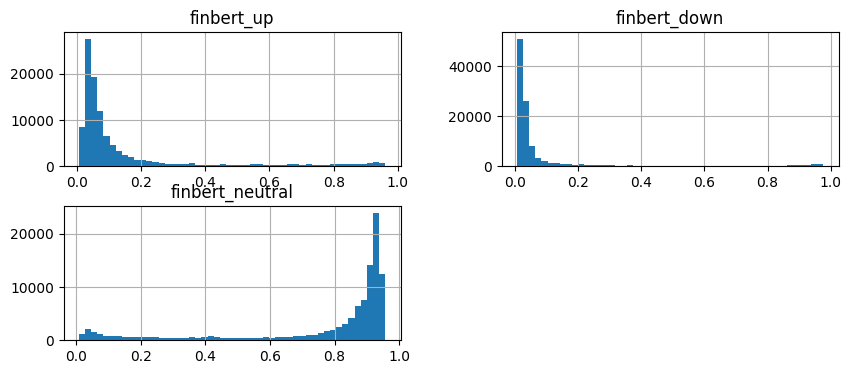

In [21]:
# Quick distribution checks
display(nlp['finbert_label'].value_counts())

# Score histograms
cols = ['finbert_up', 'finbert_down', 'finbert_neutral']
nlp[cols].hist(bins=50, figsize=(10, 4))

# Simple thresholded label counts
threshold = 0.6
threshold_labels = pd.Series('neutral', index=nlp.index)
threshold_labels[nlp['finbert_up'] > threshold] = 'positive'
threshold_labels[nlp['finbert_down'] > threshold] = 'negative'
display(threshold_labels.value_counts())